In [38]:
from scipy.interpolate import griddata
import torch
import numpy as np
import pandas as pd
import os

import matplotlib.pyplot as plt

In [54]:
lin = np.linspace(0, 1, 1000)
grid_x, grid_y = np.meshgrid(lin, lin)

In [55]:
sample_re = pd.read_csv("Data/Re_2500.csv", index_col=0)
sample_re

,x,y,u (m/s),v (m/s)
1,0.002876,0.007530,-0.000810,0.030093
2,0.002899,0.002901,-0.011855,0.010626
3,0.002936,0.013556,0.019457,-0.014841
4,0.003014,0.020054,0.044862,-0.151525
5,0.003090,0.026673,0.072048,-0.400836
...,...,...,...,...
9403,1.000000,0.986667,0.000000,0.000000
9404,0.998730,0.998730,442.754299,-729.624548
9405,0.993333,1.000000,3198.148733,4.984277
9406,1.000000,0.993333,0.000000,0.000000


In [56]:
points = np.stack((sample_re["x"], sample_re["y"]), 1)
points.shape

(9407, 2)

In [60]:
interpolated_data_u = griddata(points, sample_re["u (m/s)"], (grid_x, grid_y), method="linear", fill_value=0.0)
interpolated_data_v = griddata(points, sample_re["v (m/s)"], (grid_x, grid_y), method="linear", fill_value=0.0)
interpolated_data_v.shape

(1000, 1000)

/var/folders/3p/xlr6tgyx4t980qpxnnrs12kc0000gn/T/ipykernel_37687/3097233012.py:1: RuntimeWarning: invalid value encountered in sqrt
  plt.contourf(grid_x, grid_y, np.sqrt(interpolated_data_v * interpolated_data_u))


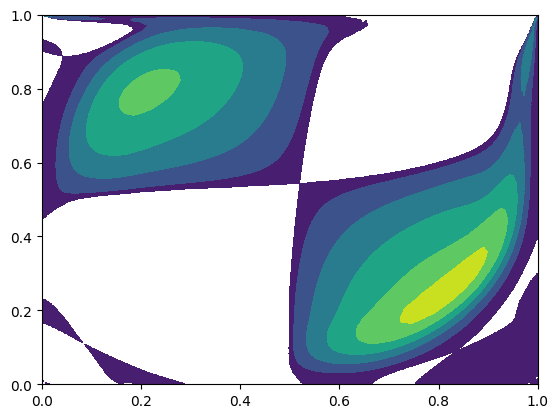

In [63]:
plt.contourf(grid_x, grid_y, np.sqrt(interpolated_data_v * interpolated_data_u))

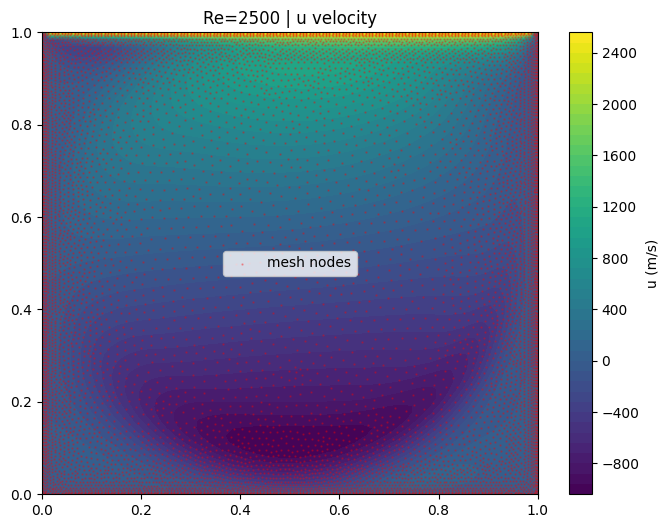

In [64]:
x = sample_re["x"].values
y = sample_re["y"].values
u = sample_re["u (m/s)"].values

# grid that covers the actual data range
grid_x, grid_y = np.meshgrid(
    np.linspace(x.min(), x.max(), 64),
    np.linspace(y.min(), y.max(), 64)
)

points = np.stack((x, y), axis=1)
interpolated_data = griddata(points, u, (grid_x, grid_y), method="linear", fill_value=0.0)

plt.figure(figsize=(8, 6))
plt.contourf(grid_x, grid_y, interpolated_data, levels=50, cmap="viridis")
plt.colorbar(label="u (m/s)")
plt.scatter(x, y, s=0.5, c="red", alpha=0.3, label="mesh nodes")  # overlay actual nodes
plt.legend()
plt.title("Re=2500 | u velocity")
plt.show()